# Notebook 02 — Covariate Assembly & Univariable Analysis
**E. coli Levofloxacin — 2-State (S vs notS)**

Replicates `script6/01_ecoli_lev_2state_cov.R`  
Input: R-generated covariate dataset (`output6/03_ecoli_lev_cov_dataset.csv`)  
Uses **polars** for the medication file range join (802 MB).

## Setup

In [12]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
from datetime import timedelta

DATA_DIR  = Path('c:/ARMD/data')
OUT_DIR   = Path('c:/ARMD/Python_Coursework_ARMD_analysis/python_output')
R_OUT_DIR = Path('c:/ARMD/output6')
OUT_DIR.mkdir(parents=True, exist_ok=True)

LOOKBACK_DAYS = 90

# Drug code groups (same as R scripts)
LEV_CODES  = ['LEV', 'LEV1', 'LEV2']
FQ_CODES   = ['CIP', 'CIP1', 'CIP2', 'CIP3', 'LEV', 'LEV1', 'LEV2',
               'OFL', 'GAT', 'MOX', 'MOX1']
TMX_CODES  = ['TMP', 'TMP1', 'SXT', 'SXT1', 'SMX']

print('Setup complete.')

Setup complete.


## 1. Load R-Generated Covariate Dataset
This skips re-deriving from the 800 MB medication file for the main analysis.
Section 2 shows how it was derived using polars (for learning).

In [13]:
cov = pd.read_csv(R_OUT_DIR / '03_ecoli_lev_cov_dataset.csv',
                  parse_dates=['order_time', 'visit_date'])

print(f'Rows: {len(cov):,}  |  Patients: {cov["anon_id"].nunique():,}')
print('Columns:', cov.columns.tolist())

Rows: 19,374  |  Patients: 6,230
Columns: ['order_proc_id_coded', 'anon_id', 'order_time', 'susceptibility', 'obs_index', 'n_obs', 'interval_days', 'visit_date', 'era_post2015', 'ampi_90d', 'ampi_days', 'tmx_90d', 'tmx_days', 'fq_90d', 'fq_days', 'outpatient', 'adi_score', 'adi_tertile', 'nh_90d']


## 2. How the 90-Day Lookback Works (polars demo)
This cell demonstrates how to do the medication range join in polars.
It filters to a small subset of patients to keep it fast.

In [14]:
# --- Polars range-join demo (subset of 500 patients) ---
demo_patients = cov['anon_id'].unique()[:500].tolist()  # list required for polars is_in()

# Load medication file, filter to demo patients only
print('Loading medication file with polars (filtered to 500 patients)...')
med_cols = ['anon_id', 'order_proc_id_coded', 'order_time_jittered_utc',
            'medication_time_to_culturetime', 'medication_name']

meds_pl = (
    pl.scan_csv(str(DATA_DIR / 'microbiology_cultures_prior_med.csv'),
                infer_schema_length=10000)
      .select(med_cols)
      .filter(pl.col('anon_id').is_in(demo_patients))
      .collect()
)
print(f'Medication rows (demo 500 pts): {len(meds_pl):,}')

# Compute absolute medication date
meds_pl = meds_pl.with_columns([
    pl.col('order_time_jittered_utc').str.to_datetime(format='%Y-%m-%dT%H:%M:%SZ', strict=False).alias('order_time'),
    pl.col('medication_time_to_culturetime').cast(pl.Float64, strict=False).alias('med_offset_days')
]).filter(
    pl.col('med_offset_days').is_not_null()
).with_columns([
    (pl.col('order_time') - pl.duration(days=pl.col('med_offset_days'))).dt.date().alias('abs_med_date')
])

# Visits for demo patients
visits_pl = pl.from_pandas(cov[cov['anon_id'].isin(demo_patients)][['anon_id','visit_date']].copy())
visits_pl = visits_pl.with_columns([
    pl.col('visit_date').cast(pl.Date).alias('win_end'),
    (pl.col('visit_date').cast(pl.Date) - pl.duration(days=LOOKBACK_DAYS)).alias('win_start')
])

# Range join: for each visit, find meds in [win_start, win_end] for same patient
joined = visits_pl.join(meds_pl.select(['anon_id', 'abs_med_date', 'medication_name']),
                        on='anon_id', how='left')
joined = joined.filter(
    (pl.col('abs_med_date') >= pl.col('win_start')) &
    (pl.col('abs_med_date') <= pl.col('win_end'))
)

print(f'In-window medication exposures found: {len(joined):,}')
print('Demo complete — the R-generated dataset (loaded above) uses this same logic at full scale.')

Loading medication file with polars (filtered to 500 patients)...
Medication rows (demo 500 pts): 109,354
In-window medication exposures found: 0
Demo complete — the R-generated dataset (loaded above) uses this same logic at full scale.


## 3. Build 2-State Dataset
Merge Intermediate + Resistant → notS.

In [15]:
cov['state_2'] = cov['susceptibility'].apply(
    lambda x: 'S' if x == 'Susceptible' else 'notS'
)

# Drop era_post2015
if 'era_post2015' in cov.columns:
    cov = cov.drop(columns=['era_post2015'])

# Build transitions from S
cov_sorted = cov.sort_values(['anon_id', 'order_time'])
cov_sorted['from_state_2'] = cov_sorted.groupby('anon_id')['state_2'].shift(1)
cov_sorted['to_state_2']   = cov_sorted['state_2']

trans = cov_sorted.dropna(subset=['from_state_2']).copy()
trans_s = trans[trans['from_state_2'] == 'S'].copy()
trans_s['y'] = (trans_s['to_state_2'] == 'notS').astype(int)

print(f'Total transitions from S: {len(trans_s):,}')
print(f'S -> notS: {trans_s["y"].sum():,}  ({trans_s["y"].mean()*100:.1f}%)')

Total transitions from S: 11,634
S -> notS: 1,319  (11.3%)


## 4. 2×2 Transition Matrix

In [16]:
counts2 = trans.groupby(['from_state_2', 'to_state_2']).size().reset_index(name='N')
totals2 = counts2.groupby('from_state_2')['N'].transform('sum')
counts2['total']      = totals2
counts2['proportion'] = (counts2['N'] / counts2['total']).round(4)
counts2['transition'] = counts2['from_state_2'] + '->' + counts2['to_state_2']
counts2.to_csv(OUT_DIR / '02_ecoli_lev_transition_matrix_2state.csv', index=False)
print(counts2.to_string(index=False))

from_state_2 to_state_2     N  total  proportion transition
           S          S 10315  11634      0.8866       S->S
           S       notS  1319  11634      0.1134    S->notS
        notS          S   385   1510      0.2550    notS->S
        notS       notS  1125   1510      0.7450 notS->notS


## 5. Covariate Distribution Summary

In [17]:
binary_covs = ['fq_90d', 'tmx_90d', 'outpatient', 'nh_90d']
# ampi_90d is from the amp analysis; for lev we check fq/tmx as prior antibiotics
# Use only columns that actually exist
binary_covs = [c for c in binary_covs if c in trans_s.columns]

rows = []
for cov_name in binary_covs:
    sub = trans_s[[cov_name, 'y']].dropna()
    n_total = len(sub)
    n_exp   = sub[cov_name].sum()
    pct_exp = 100 * n_exp / n_total if n_total > 0 else 0

    s2s  = sub[sub['y'] == 0]
    s2ns = sub[sub['y'] == 1]

    rows.append({
        'covariate':         cov_name,
        'N_total':           n_total,
        'N_exposed':         int(n_exp),
        'pct_exposed':       round(pct_exp, 1),
        'N_exposed_S2S':     int(s2s[cov_name].sum()),
        'pct_S2S':           round(100 * s2s[cov_name].sum() / len(s2s), 1) if len(s2s) > 0 else 0,
        'N_exposed_S2notS':  int(s2ns[cov_name].sum()),
        'pct_S2notS':        round(100 * s2ns[cov_name].sum() / len(s2ns), 1) if len(s2ns) > 0 else 0,
    })

dist_df = pd.DataFrame(rows)
dist_df.to_csv(OUT_DIR / '02_ecoli_lev_cov_distribution.csv', index=False)
print(dist_df.to_string(index=False))

 covariate  N_total  N_exposed  pct_exposed  N_exposed_S2S  pct_S2S  N_exposed_S2notS  pct_S2notS
    fq_90d    11634       1790         15.4           1452     14.1               338        25.6
   tmx_90d    11634       1206         10.4           1054     10.2               152        11.5
outpatient    11634       6829         58.7           6117     59.3               712        54.0
    nh_90d    11634         62          0.5             44      0.4                18         1.4


## 6. Missing Data

In [18]:
all_covs = ['fq_90d', 'fq_days', 'tmx_90d', 'tmx_days',
            'outpatient', 'adi_score', 'adi_tertile', 'nh_90d']
all_covs = [c for c in all_covs if c in cov.columns]

missing = pd.DataFrame({
    'covariate': all_covs,
    'N_total':   len(cov),
    'N_missing': [cov[c].isna().sum() for c in all_covs],
})
missing['pct_missing'] = (missing['N_missing'] / missing['N_total'] * 100).round(1)
missing.to_csv(OUT_DIR / '02_ecoli_lev_cov_missing.csv', index=False)
print(missing.to_string(index=False))

  covariate  N_total  N_missing  pct_missing
     fq_90d    19374          0          0.0
    fq_days    19374      16644         85.9
    tmx_90d    19374          0          0.0
   tmx_days    19374      17440         90.0
 outpatient    19374          0          0.0
  adi_score    19374       3848         19.9
adi_tertile    19374       3848         19.9
     nh_90d    19374          0          0.0


## 7. Univariable Logistic Regression (cluster-robust SEs)

In [19]:
cov_specs = [
    ('fq_90d',    'Prior FQ 90d',           'binary',     1),
    ('fq_days',   'Days since last FQ',      'continuous', 1),
    ('tmx_90d',   'Prior TMP-SMX 90d',       'binary',     1),
    ('tmx_days',  'Days since last TMP-SMX', 'continuous', 1),
    ('outpatient','Outpatient setting',       'binary',     2),
    ('adi_score', 'ADI score',                'continuous', 3),
    ('nh_90d',    'Nursing home 90d',         'binary',     3),
]
cov_specs = [s for s in cov_specs if s[0] in trans_s.columns]

results = []

for var, label, vtype, tier in cov_specs:
    sub = trans_s[['anon_id', var, 'y']].dropna()
    N = len(sub)

    if N < 5:
        results.append({'tier': tier, 'covariate': label, 'variable': var,
                        'type': vtype, 'N': N, 'OR': None, 'CI_lo': None,
                        'CI_hi': None, 'p_value': None, 'note': 'too few obs'})
        continue

    x = sub[var].copy()

    if vtype == 'continuous':
        scale = 10.0 if var == 'adi_score' else x.std()
        if scale == 0 or np.isnan(scale):
            scale = 1.0
        x_scaled = x / scale
        n_desc = 'median=' + str(int(x.median()))
        note = 'OR per 10 units' if var == 'adi_score' else 'OR per 1 SD'
    else:
        x_scaled = x
        n_exp = int(x.sum())
        n_desc = str(n_exp) + '/' + str(N)
        note = '1 vs 0'

    try:
        X = sm.add_constant(x_scaled)
        model = sm.Logit(sub['y'], X).fit(
            cov_type='cluster', cov_kwds={'groups': sub['anon_id'].values}, disp=0
        )
        coef = model.params[var]
        ci   = model.conf_int()
        pval = model.pvalues[var]
        results.append({
            'tier': tier, 'covariate': label, 'variable': var,
            'type': vtype, 'N': N, 'N_exposed_or_median': n_desc,
            'OR':    round(float(np.exp(coef)), 3),
            'CI_lo': round(float(np.exp(ci.loc[var, 0])), 3),
            'CI_hi': round(float(np.exp(ci.loc[var, 1])), 3),
            'p_value': round(float(pval), 4),
            'note': note
        })
    except Exception as e:
        results.append({'tier': tier, 'covariate': label, 'variable': var,
                        'type': vtype, 'N': N, 'OR': None, 'CI_lo': None,
                        'CI_hi': None, 'p_value': None, 'note': str(e)})

uni_df = pd.DataFrame(results)
uni_df.to_csv(OUT_DIR / '02_ecoli_lev_univariable_results.csv', index=False)
print(uni_df[['covariate','N','OR','CI_lo','CI_hi','p_value','note']].to_string(index=False))

              covariate     N    OR  CI_lo  CI_hi  p_value            note
           Prior FQ 90d 11634 2.103  1.830  2.417   0.0000          1 vs 0
     Days since last FQ  1790 1.193  1.072  1.327   0.0012     OR per 1 SD
      Prior TMP-SMX 90d 11634 1.144  0.955  1.371   0.1429          1 vs 0
Days since last TMP-SMX  1206 1.145  0.975  1.345   0.0988     OR per 1 SD
     Outpatient setting 11634 0.805  0.715  0.906   0.0003          1 vs 0
              ADI score  9345 1.111  1.027  1.203   0.0090 OR per 10 units
       Nursing home 90d 11634 3.230  1.854  5.627   0.0000          1 vs 0


### Validation vs R

In [20]:
r_uni = pd.read_csv(R_OUT_DIR / '03_ecoli_lev_univariable_results.csv')
print('--- R binary covariate ORs ---')
print(r_uni[r_uni['type']=='binary'][['covariate','OR','CI_lo','CI_hi','p_value']].to_string(index=False))
print()
print('--- Python binary covariate ORs ---')
print(uni_df[uni_df['type']=='binary'][['covariate','OR','CI_lo','CI_hi','p_value']].to_string(index=False))

--- R binary covariate ORs ---
                         covariate    OR  CI_lo  CI_hi  p_value
Prior fluoroquinolone 90d (binary) 2.103  1.830  2.417   0.0000
Prior ampicillin/amox 90d (binary) 1.547  1.225  1.955   0.0003
        Prior TMP-SMX 90d (binary) 1.144  0.955  1.371   0.1428
                Outpatient setting 0.805  0.715  0.906   0.0003
                     Era post-2015 1.229  1.063  1.421   0.0053
          Nursing home visit (90d) 3.230  1.854  5.627   0.0000

--- Python binary covariate ORs ---
         covariate    OR  CI_lo  CI_hi  p_value
      Prior FQ 90d 2.103  1.830  2.417   0.0000
 Prior TMP-SMX 90d 1.144  0.955  1.371   0.1429
Outpatient setting 0.805  0.715  0.906   0.0003
  Nursing home 90d 3.230  1.854  5.627   0.0000


## 8. Forest Plot

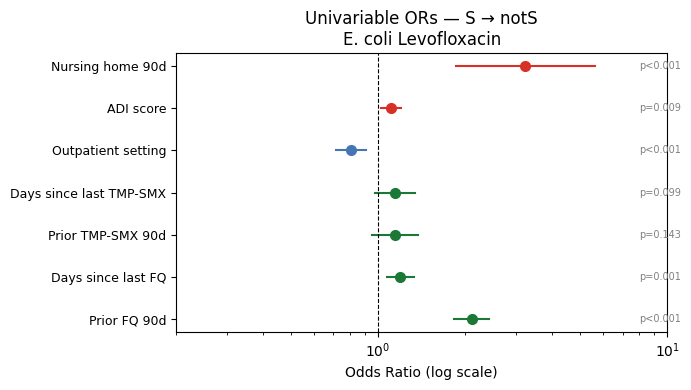

In [21]:
plot_df = uni_df.dropna(subset=['OR', 'CI_lo', 'CI_hi']).copy()
tier_colors = {1: '#1b7837', 2: '#4575b4', 3: '#d73027'}

fig, ax = plt.subplots(figsize=(7, max(4, len(plot_df) * 0.5)))

for i, row in plot_df.reset_index(drop=True).iterrows():
    color = tier_colors.get(row['tier'], 'black')
    ax.plot(row['OR'], i, 'o', color=color, ms=7, zorder=3)
    ax.plot([row['CI_lo'], row['CI_hi']], [i, i], '-', color=color, lw=1.5)

ax.axvline(1, color='black', lw=0.8, linestyle='--')
ax.set_xscale('log')
ax.set_xlim(0.2, 10)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['covariate'].tolist(), fontsize=9)
ax.set_xlabel('Odds Ratio (log scale)')
ax.set_title('Univariable ORs — S → notS\nE. coli Levofloxacin')

# Add p-value annotations
for i, row in plot_df.reset_index(drop=True).iterrows():
    if pd.notna(row['p_value']):
        plab = f'p={row["p_value"]:.3f}' if row['p_value'] >= 0.001 else 'p<0.001'
        ax.text(8, i, plab, va='center', fontsize=7, color='grey')

plt.tight_layout()
plt.savefig(OUT_DIR / '02_ecoli_lev_univariable_forest.png', dpi=150)
plt.show()

## 9. Binary Covariate Barplot

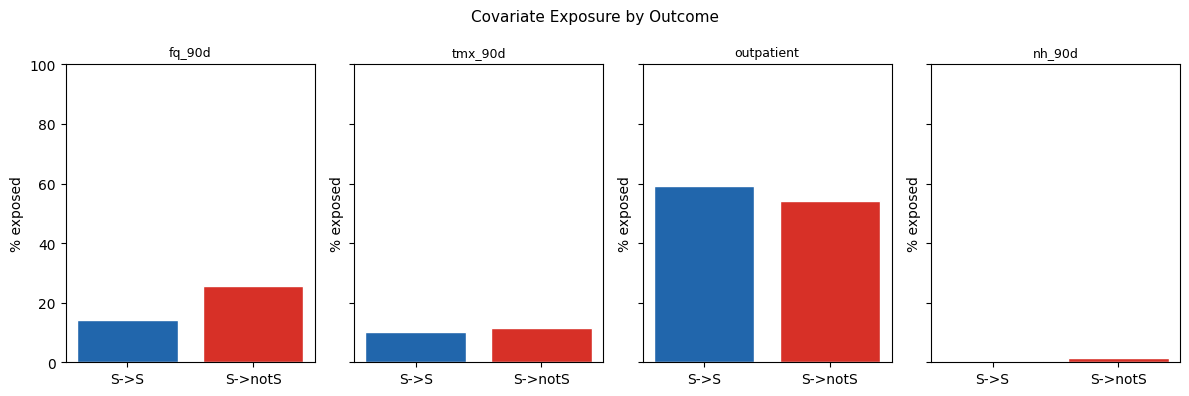

In [22]:
bin_vars = [s[0] for s in cov_specs if s[2] == 'binary' and s[0] in trans_s.columns]

fig, axes = plt.subplots(1, len(bin_vars), figsize=(3 * len(bin_vars), 4), sharey=True)
if len(bin_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, bin_vars):
    sub = trans_s[['y', var]].dropna()
    grp = sub.groupby('y')[var].mean().reset_index()
    grp['label'] = grp['y'].map({0: 'S->S', 1: 'S->notS'})
    ax.bar(grp['label'], grp[var] * 100,
           color=['#2166ac', '#d73027'], edgecolor='white')
    ax.set_title(var, fontsize=9)
    ax.set_ylabel('% exposed')
    ax.set_ylim(0, 100)

plt.suptitle('Covariate Exposure by Outcome', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / '02_ecoli_lev_cov_barplot.png', dpi=150)
plt.show()